# Per-founder h on 8 SEEDMIX replicates — cactus_em vs cactus_em-filt2 vs hapFIRE

Each panel below shows the per-founder h vector from one of 8 SEEDMIX_S1..S8
technical replicates. Reads are Trimmomatic-trimmed + Clumpify-deduped from
`/global/home/users/tbellg/scratch/pang/grenenet_reads/seed_mix_trimmed/dedup/`.

- **cactus_em** (baseline): cactus founders = blue, PG founders = orange
- **cactus_em-filt2** (drop k-mers carried by <2 founders): cactus = navy, PG = darkorange
- **hapFIRE** (independent estimator on GrENE-Net SNP catalog): green
- **Red dashed line** = 1/231 ≈ 0.00433, the recipe expectation under a perfectly
  uniform seedmix

The 8 replicates are technical replicates of the same recipe — variance across
them is the per-method noise floor.

**Caveat:** the recipe is the *intended* composition. The realized seedmix may
have germination/extraction biases. "h_est = 1/231 exactly" is the model
expectation, not a verified ground truth.


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('/global/scratch/users/tbellg/hapfire_sv')
CEM_DIR = ROOT / 'scratch/seedmix_v3_dedup'
CEM_FILT2_DIR = ROOT / 'scratch/seedmix_v3_filt2_dedup'
HF_DIR = Path('/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix')
SAMPLES_FILE = ROOT / 'data/vcf_samples_231.txt'
SPLIT_FILE = ROOT / 'data/founder_split_cactus_pg.json'

founders = [l.strip() for l in open(SAMPLES_FILE)]
F = len(founders)
split = json.load(open(SPLIT_FILE))
cactus_set = set(split['cactus']); pg_set = set(split['PG'])
is_cactus = np.array([f in cactus_set for f in founders])
is_pg = np.array([f in pg_set for f in founders])
TRUTH = 1.0 / F
print(f'founders: {F} ({is_cactus.sum()} cactus + {is_pg.sum()} PG)')
print(f'expected h per founder under recipe: 1/231 = {TRUTH:.5f}')


founders: 231 (80 cactus + 151 PG)
expected h per founder under recipe: 1/231 = 0.00433


In [2]:
def load_cem(d, s):
    z = np.load(d / f'SEEDMIX_S{s}.h_per_chrom.npz', allow_pickle=True)
    h = np.mean([z[c] for c in ['Chr1','Chr2','Chr3','Chr4','Chr5'] if c in z], axis=0)
    return h / h.sum()

def load_hapfire(s):
    df = pd.read_csv(HF_DIR / f's{s}_ecotype_frequency.txt', sep='\t',
                     header=None, names=['eco','h'])
    df['eco'] = df['eco'].astype(str)
    fmap = dict(zip(df['eco'], df['h']))
    h = np.array([fmap.get(f, 0.0) for f in founders])
    return h / h.sum()

cem      = np.stack([load_cem(CEM_DIR, s) for s in range(1, 9)])
filt2    = np.stack([load_cem(CEM_FILT2_DIR, s) for s in range(1, 9)])
hf       = np.stack([load_hapfire(s) for s in range(1, 9)])
print(f'cem: {cem.shape}, filt2: {filt2.shape}, hf: {hf.shape}')
print(f'sums (sanity): cem={cem.sum(axis=1).round(4)}\n               filt2={filt2.sum(axis=1).round(4)}\n               hf={hf.sum(axis=1).round(4)}')


cem: (8, 231), filt2: (8, 231), hf: (8, 231)
sums (sanity): cem=[1. 1. 1. 1. 1. 1. 1. 1.]
               filt2=[1. 1. 1. 1. 1. 1. 1. 1.]
               hf=[1. 1. 1. 1. 1. 1. 1. 1.]


## Per-founder h, one panel per replicate

x-axis: founder index (alphabetical order in panel = `data/vcf_samples_231.txt`).
y-axis: estimated h.


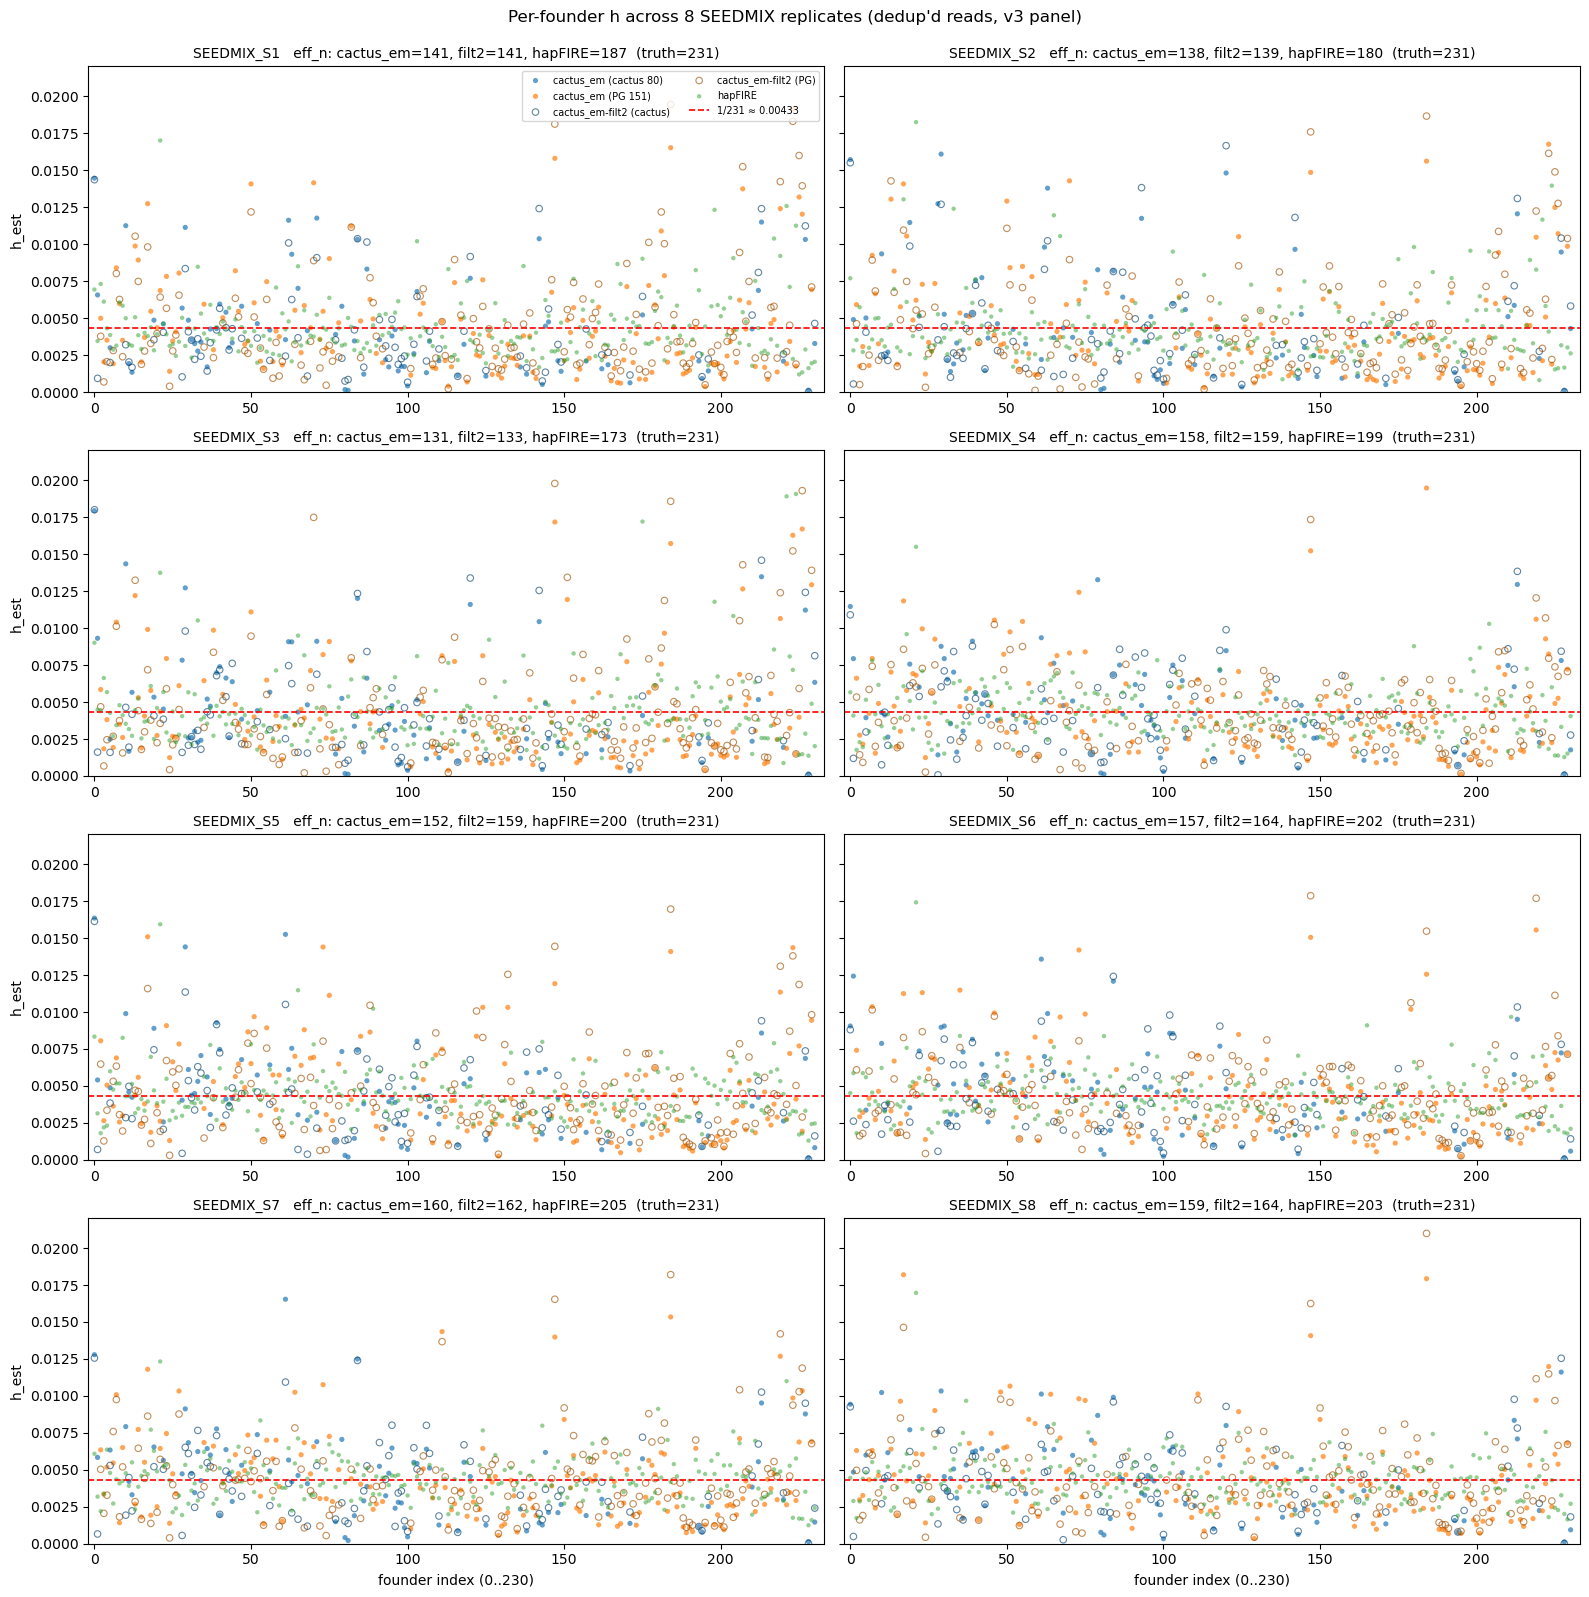

In [3]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16), sharey=True)
axes = axes.flatten()
x = np.arange(F)

for s, ax in zip(range(1, 9), axes):
    # cactus_em points by class
    ax.scatter(x[is_cactus], cem[s-1, is_cactus],
               s=14, alpha=0.7, color='#1f77b4', label='cactus_em (cactus 80)', edgecolors='none')
    ax.scatter(x[is_pg],     cem[s-1, is_pg],
               s=14, alpha=0.7, color='#ff7f0e', label='cactus_em (PG 151)', edgecolors='none')
    # cactus_em-filt2 (smaller, hollow markers for visual distinction)
    ax.scatter(x[is_cactus], filt2[s-1, is_cactus],
               s=22, alpha=0.65, facecolors='none', edgecolors='#0a4470', linewidths=0.8,
               label='cactus_em-filt2 (cactus)')
    ax.scatter(x[is_pg],     filt2[s-1, is_pg],
               s=22, alpha=0.65, facecolors='none', edgecolors='#a05000', linewidths=0.8,
               label='cactus_em-filt2 (PG)')
    # hapFIRE in green
    ax.scatter(x, hf[s-1], s=10, alpha=0.5, color='#2ca02c', label='hapFIRE', edgecolors='none')
    # expectation
    ax.axhline(TRUTH, color='red', linestyle='--', lw=1.2, label=f'1/231 ≈ {TRUTH:.5f}')
    ymax = max(cem[s-1].max(), filt2[s-1].max(), hf[s-1].max()) * 1.05
    ax.set_xlim(-2, F+2); ax.set_ylim(0, ymax)
    eff_cem   = 1.0 / np.sum(cem[s-1] ** 2)
    eff_filt2 = 1.0 / np.sum(filt2[s-1] ** 2)
    eff_hf    = 1.0 / np.sum(hf[s-1] ** 2)
    ax.set_title(f'SEEDMIX_S{s}   eff_n: cactus_em={eff_cem:.0f}, filt2={eff_filt2:.0f}, hapFIRE={eff_hf:.0f}  (truth=231)',
                 fontsize=10)
    if s == 1:
        ax.legend(fontsize=7, loc='upper right', ncol=2)
    if s % 2 == 1:
        ax.set_ylabel('h_est')
    if s >= 7:
        ax.set_xlabel('founder index (0..230)')

fig.suptitle('Per-founder h across 8 SEEDMIX replicates (dedup\'d reads, v3 panel)',
              y=0.995, fontsize=12)
plt.tight_layout()
plt.show()


## Rank-sorted: shows the over-concentration shape per method


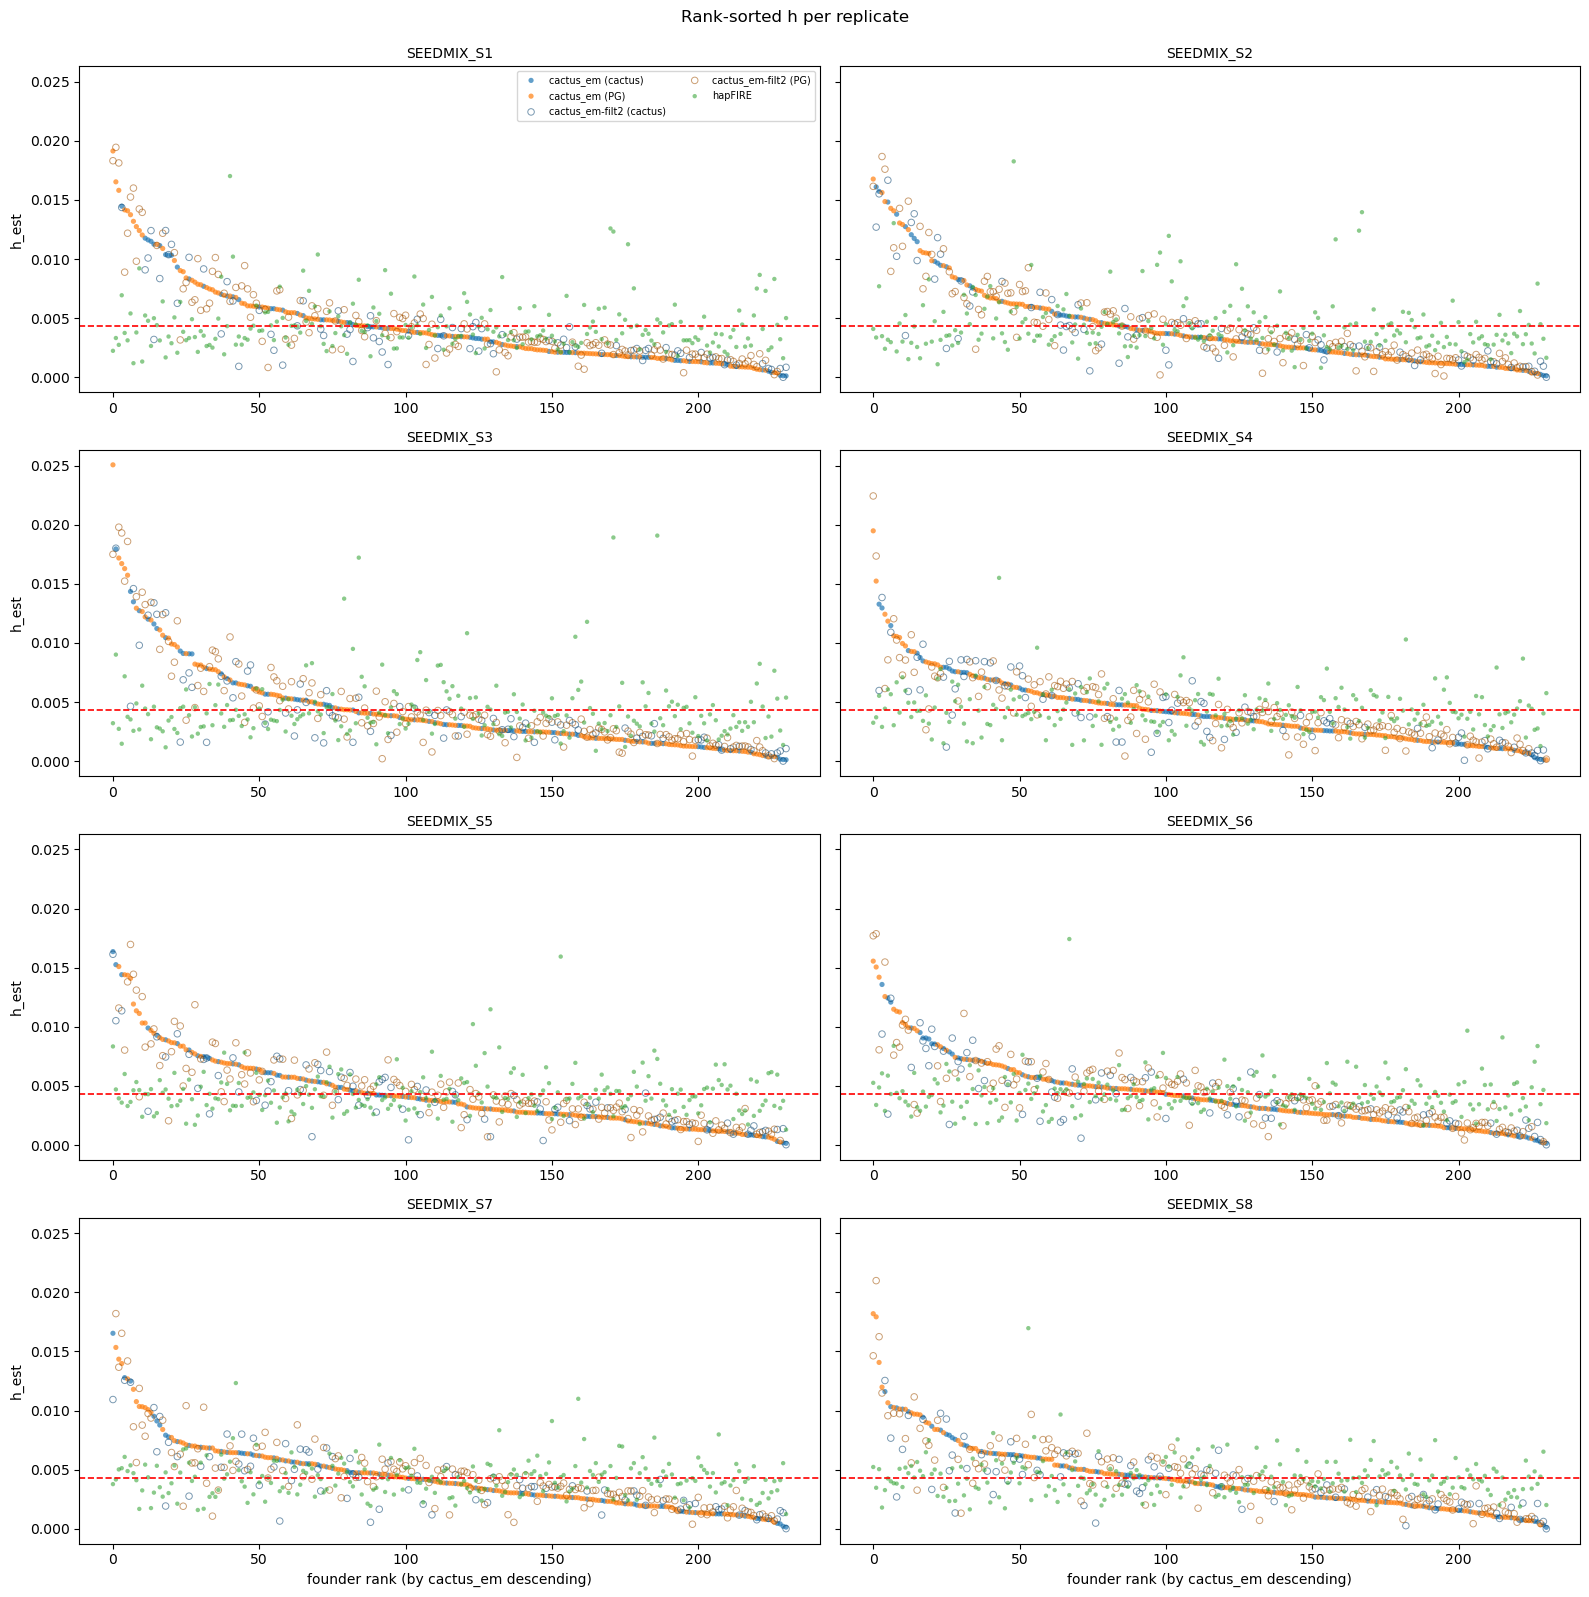

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16), sharey=True)
axes = axes.flatten()

for s, ax in zip(range(1, 9), axes):
    order = np.argsort(-cem[s-1])  # rank by cactus_em descending
    rank = np.arange(F)
    # cactus_em (color by class at right rank)
    for cls_mask, color, label in [
        (is_cactus, '#1f77b4', 'cactus_em (cactus)'),
        (is_pg,     '#ff7f0e', 'cactus_em (PG)'),
    ]:
        cls_ranks = np.array([np.where(order == i)[0][0] for i in np.where(cls_mask)[0]])
        ax.scatter(cls_ranks, cem[s-1, np.where(cls_mask)[0]],
                   s=14, alpha=0.7, color=color, label=label, edgecolors='none')
    # filt2 on cactus_em rank — open markers
    for cls_mask, color, label in [
        (is_cactus, '#0a4470', 'cactus_em-filt2 (cactus)'),
        (is_pg,     '#a05000', 'cactus_em-filt2 (PG)'),
    ]:
        cls_ranks = np.array([np.where(order == i)[0][0] for i in np.where(cls_mask)[0]])
        ax.scatter(cls_ranks, filt2[s-1, np.where(cls_mask)[0]],
                   s=22, alpha=0.55, facecolors='none', edgecolors=color, linewidths=0.7,
                   label=label)
    # hapFIRE — re-order by same cactus_em rank
    ax.scatter(rank, hf[s-1, order], s=10, alpha=0.55, color='#2ca02c',
               label='hapFIRE', edgecolors='none')
    ax.axhline(TRUTH, color='red', linestyle='--', lw=1.2)
    ax.set_title(f'SEEDMIX_S{s}', fontsize=10)
    if s == 1:
        ax.legend(fontsize=7, loc='upper right', ncol=2)
    if s % 2 == 1:
        ax.set_ylabel('h_est')
    if s >= 7:
        ax.set_xlabel('founder rank (by cactus_em descending)')

fig.suptitle('Rank-sorted h per replicate', y=0.995, fontsize=12)
plt.tight_layout()
plt.show()


## Summary table per replicate


In [5]:
rows = []
for s in range(1, 9):
    for method, h in [('cactus_em', cem[s-1]), ('cactus_em-filt2', filt2[s-1]), ('hapFIRE', hf[s-1])]:
        rows.append(dict(
            replicate=s, method=method,
            eff_n=1.0/np.sum(h**2),
            L1_to_uniform=np.sum(np.abs(h - TRUTH)),
            cactus_mass=h[is_cactus].sum(),
            pg_mass=h[is_pg].sum(),
            over_cactus=h[is_cactus].sum() / 0.3463,
            over_pg=h[is_pg].sum() / 0.6537,
        ))
df = pd.DataFrame(rows)
print(df.to_string(index=False, float_format='%.4f'))


 replicate          method    eff_n  L1_to_uniform  cactus_mass  pg_mass  over_cactus  over_pg
         1       cactus_em 141.4070         0.5931       0.3374   0.6626       0.9742   1.0137
         1 cactus_em-filt2 140.5027         0.5848       0.3160   0.6840       0.9124   1.0464
         1         hapFIRE 187.4484         0.3363       0.3186   0.6814       0.9201   1.0423
         2       cactus_em 137.5062         0.6242       0.3647   0.6353       1.0530   0.9719
         2 cactus_em-filt2 139.3517         0.5978       0.3424   0.6576       0.9888   1.0059
         2         hapFIRE 179.8671         0.3650       0.3239   0.6761       0.9354   1.0342
         3       cactus_em 131.0700         0.6324       0.3550   0.6450       1.0251   0.9867
         3 cactus_em-filt2 132.9232         0.6064       0.3314   0.6686       0.9571   1.0227
         3         hapFIRE 172.8597         0.3751       0.3186   0.6814       0.9200   1.0424
         4       cactus_em 158.3853         0.5161